In [1]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import ccxt

exchange = ccxt.coinbase()

print(exchange)

Coinbase Advanced


In [5]:
symbol = 'BTC/USD'

trades = exchange.fetch_trades(symbol, limit=1000)

print(trades[:3])

[{'info': {'trade_id': '1018337231', 'product_id': 'BTC-USD', 'price': '81441.79', 'size': '0.00116466', 'time': '2026-05-14T21:54:49.502960Z', 'side': 'SELL', 'bid': '', 'ask': '', 'exchange': 'coinbase'}, 'id': '1018337231', 'order': None, 'timestamp': 1778795689502, 'datetime': '2026-05-14T21:54:49.502960Z', 'symbol': 'BTC/USD', 'type': None, 'side': 'sell', 'takerOrMaker': None, 'price': 81441.79, 'amount': 0.00116466, 'cost': 94.8519951414, 'fee': {'cost': None, 'currency': None}, 'fees': []}, {'info': {'trade_id': '1018337232', 'product_id': 'BTC-USD', 'price': '81441.79', 'size': '0.00008505', 'time': '2026-05-14T21:54:49.979639Z', 'side': 'SELL', 'bid': '', 'ask': '', 'exchange': 'coinbase'}, 'id': '1018337232', 'order': None, 'timestamp': 1778795689979, 'datetime': '2026-05-14T21:54:49.979639Z', 'symbol': 'BTC/USD', 'type': None, 'side': 'sell', 'takerOrMaker': None, 'price': 81441.79, 'amount': 8.505e-05, 'cost': 6.9266242395, 'fee': {'cost': None, 'currency': None}, 'fees': 

In [6]:
trades_df = pd.DataFrame(trades)

trades_df['datetime'] = pd.to_datetime(
    trades_df['timestamp'],
    unit='ms'
)

trades_df.head()

,info,id,order,timestamp,datetime,symbol,type,side,takerOrMaker,price,amount,cost,fee,fees
0,"{'trade_id': '1018337231', 'product_id': 'BTC-...",1018337231,None,1778795689502,2026-05-14 21:54:49.502,BTC/USD,None,sell,None,81441.79,1.164660e-03,94.851995,"{'cost': None, 'currency': None}",[]
1,"{'trade_id': '1018337232', 'product_id': 'BTC-...",1018337232,None,1778795689979,2026-05-14 21:54:49.979,BTC/USD,None,sell,None,81441.79,8.505000e-05,6.926624,"{'cost': None, 'currency': None}",[]
2,"{'trade_id': '1018337233', 'product_id': 'BTC-...",1018337233,None,1778795690019,2026-05-14 21:54:50.019,BTC/USD,None,sell,None,81441.79,1.200000e-07,0.009773,"{'cost': None, 'currency': None}",[]
3,"{'trade_id': '1018337234', 'product_id': 'BTC-...",1018337234,None,1778795690290,2026-05-14 21:54:50.290,BTC/USD,None,buy,None,81441.78,1.000000e-07,0.008144,"{'cost': None, 'currency': None}",[]
4,"{'trade_id': '1018337235', 'product_id': 'BTC-...",1018337235,None,1778795690449,2026-05-14 21:54:50.449,BTC/USD,None,sell,None,81441.79,1.222890e-03,99.594351,"{'cost': None, 'currency': None}",[]


In [7]:
# Keep only useful columns

trades_df = trades_df[
    ['datetime', 'price', 'amount', 'side']
].copy()

# Rename amount -> volume
trades_df.rename(columns={'amount': 'volume'}, inplace=True)

# Convert numeric columns
trades_df['price'] = pd.to_numeric(trades_df['price'])
trades_df['volume'] = pd.to_numeric(trades_df['volume'])

# Sort chronologically
trades_df.sort_values('datetime', inplace=True)

trades_df.head()

,datetime,price,volume,side
0,2026-05-14 21:54:49.502,81441.79,1.164660e-03,sell
1,2026-05-14 21:54:49.979,81441.79,8.505000e-05,sell
2,2026-05-14 21:54:50.019,81441.79,1.200000e-07,sell
3,2026-05-14 21:54:50.290,81441.78,1.000000e-07,buy
4,2026-05-14 21:54:50.449,81441.79,1.222890e-03,sell


In [8]:
# Signed volume:
# Buy trades = positive
# Sell trades = negative

trades_df['signed_volume'] = np.where(
    trades_df['side'] == 'buy',
    trades_df['volume'],
    -trades_df['volume']
)

trades_df.head()

,datetime,price,volume,side,signed_volume
0,2026-05-14 21:54:49.502,81441.79,1.164660e-03,sell,-1.164660e-03
1,2026-05-14 21:54:49.979,81441.79,8.505000e-05,sell,-8.505000e-05
2,2026-05-14 21:54:50.019,81441.79,1.200000e-07,sell,-1.200000e-07
3,2026-05-14 21:54:50.290,81441.78,1.000000e-07,buy,1.000000e-07
4,2026-05-14 21:54:50.449,81441.79,1.222890e-03,sell,-1.222890e-03


In [9]:
# Rolling OFI over last 50 trades

trades_df['ofi'] = (
    trades_df['signed_volume']
    .rolling(window=50)
    .sum()
)

trades_df[['datetime', 'signed_volume', 'ofi']].tail()

,datetime,signed_volume,ofi
95,2026-05-14 21:55:03.084,-1.164500e-04,0.318919
98,2026-05-14 21:55:03.096,6.109670e-03,0.325269
96,2026-05-14 21:55:03.096,1.700000e-07,0.325329
97,2026-05-14 21:55:03.096,1.616000e-05,0.325652
99,2026-05-14 21:55:04.157,1.159700e-02,0.339156


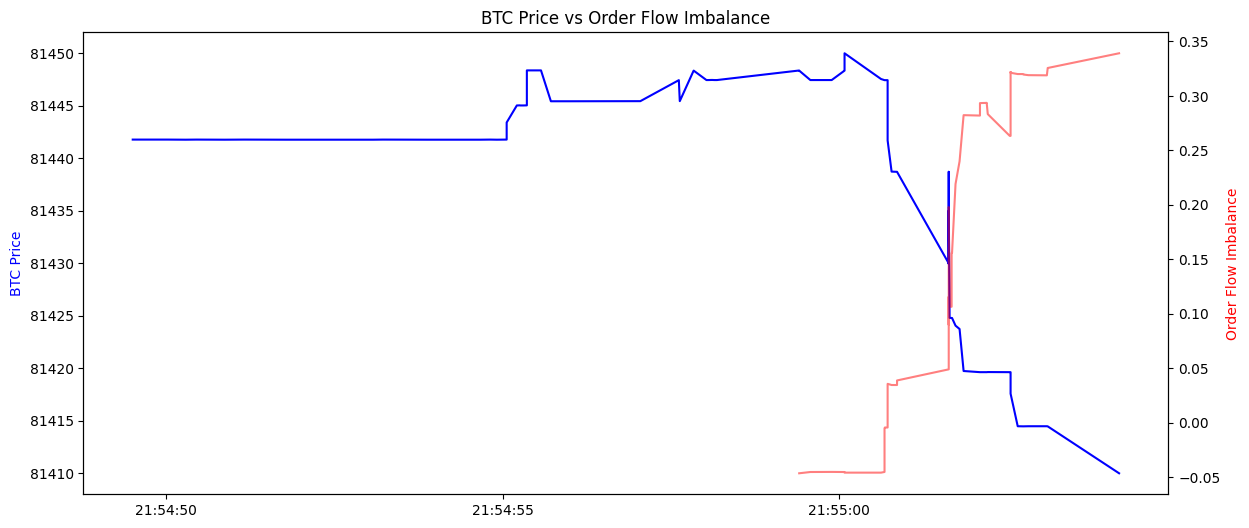

In [10]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Price
ax1.plot(
    trades_df['datetime'],
    trades_df['price'],
    color='blue',
    label='Price'
)

ax1.set_ylabel("BTC Price", color='blue')

# Second axis for OFI
ax2 = ax1.twinx()

ax2.plot(
    trades_df['datetime'],
    trades_df['ofi'],
    color='red',
    alpha=0.5,
    label='OFI'
)

ax2.set_ylabel("Order Flow Imbalance", color='red')

plt.title("BTC Price vs Order Flow Imbalance")

plt.show()

In [11]:
# Log returns

trades_df['returns'] = np.log(
    trades_df['price'] /
    trades_df['price'].shift(1)
)

trades_df[['price', 'returns']].head()

,price,returns
0,81441.79,NaN
1,81441.79,0.000000e+00
2,81441.79,0.000000e+00
3,81441.78,-1.227871e-07
4,81441.79,1.227871e-07


In [12]:
# Total traded volume

total_volume = trades_df['volume'].sum()

# Number of buckets
n_buckets = 50

# Bucket size
bucket_size = total_volume / n_buckets

print("Bucket Size:", bucket_size)

Bucket Size: 0.013881543599999999


In [13]:
# Cumulative volume

trades_df['cum_volume'] = trades_df['volume'].cumsum()

# Assign volume buckets

trades_df['bucket'] = (
    trades_df['cum_volume'] // bucket_size
).astype(int)

trades_df[['volume', 'cum_volume', 'bucket']].head()

,volume,cum_volume,bucket
0,1.164660e-03,0.001165,0
1,8.505000e-05,0.001250,0
2,1.200000e-07,0.001250,0
3,1.000000e-07,0.001250,0
4,1.222890e-03,0.002473,0


In [14]:
vpin_list = []

for bucket in trades_df['bucket'].unique():
    
    bucket_data = trades_df[
        trades_df['bucket'] == bucket
    ]
    
    buy_volume = bucket_data[
        bucket_data['side'] == 'buy'
    ]['volume'].sum()
    
    sell_volume = bucket_data[
        bucket_data['side'] == 'sell'
    ]['volume'].sum()
    
    total_bucket_volume = buy_volume + sell_volume
    
    if total_bucket_volume > 0:
        
        imbalance = abs(
            buy_volume - sell_volume
        ) / total_bucket_volume
        
    else:
        imbalance = 0
        
    vpin_list.append({
        'bucket': bucket,
        'vpin': imbalance
    })

vpin_df = pd.DataFrame(vpin_list)

vpin_df.head()

,bucket,vpin
0,0,0.930358
1,1,1.000000
2,2,1.000000
3,9,1.000000
4,10,0.324233


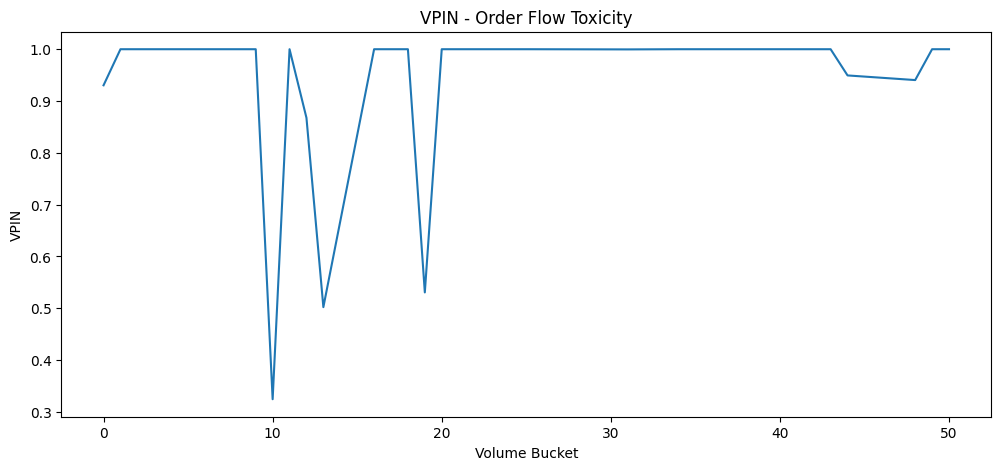

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    vpin_df['bucket'],
    vpin_df['vpin']
)

plt.title("VPIN - Order Flow Toxicity")
plt.xlabel("Volume Bucket")
plt.ylabel("VPIN")

plt.show()

# ====================================
# Minute-Level Aggregation
# ====================================

In [16]:
# Set datetime index

trades_df = trades_df.set_index('datetime')

# 1-minute aggregation

minute_df = trades_df.resample('1min').agg({
    'price': 'last',
    'volume': 'sum',
    'signed_volume': 'sum'
})

# Rename OFI proxy

minute_df.rename(columns={
    'signed_volume': 'ofi'
}, inplace=True)

# Drop missing rows

minute_df.dropna(inplace=True)

minute_df.head()

,price,volume,ofi
datetime,,,
2026-05-14 21:54:00,81447.46,0.183887,-0.046206
2026-05-14 21:55:00,81410.01,0.510190,0.339155


In [17]:
# Log returns

minute_df['returns'] = np.log(
    minute_df['price'] /
    minute_df['price'].shift(1)
)

# Rolling volatility

minute_df['volatility'] = (
    minute_df['returns']
    .rolling(10)
    .std()
)

minute_df.head()

,price,volume,ofi,returns,volatility
datetime,,,,,
2026-05-14 21:54:00,81447.46,0.183887,-0.046206,NaN,NaN
2026-05-14 21:55:00,81410.01,0.510190,0.339155,-0.00046,NaN


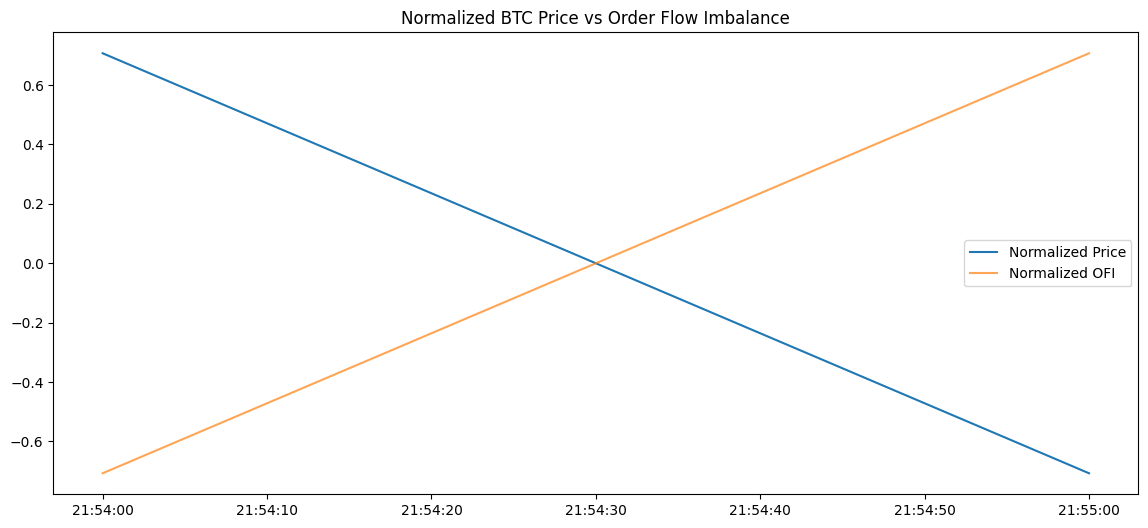

In [19]:
# Normalize both series

plot_df = minute_df[['price', 'ofi']].copy()

plot_df['price_norm'] = (
    plot_df['price'] - plot_df['price'].mean()
) / plot_df['price'].std()

plot_df['ofi_norm'] = (
    plot_df['ofi'] - plot_df['ofi'].mean()
) / plot_df['ofi'].std()

# Plot

plt.figure(figsize=(14,6))

plt.plot(
    plot_df.index,
    plot_df['price_norm'],
    label='Normalized Price'
)

plt.plot(
    plot_df.index,
    plot_df['ofi_norm'],
    label='Normalized OFI',
    alpha=0.7
)

plt.title("Normalized BTC Price vs Order Flow Imbalance")

plt.legend()

plt.show()

In [20]:
# ==========================================
# RAW DATA VALIDATION
# ==========================================

print("Shape:")
print(trades_df.shape)

print("\nColumns:")
print(trades_df.columns.tolist())

print("\nData Types:")
print(trades_df.dtypes)

print("\nMissing Values:")
print(trades_df.isnull().sum())

print("\nFirst 5 Rows:")
display(trades_df.head())

print("\nLast 5 Rows:")
display(trades_df.tail())

Shape:
(100, 8)

Columns:
['price', 'volume', 'side', 'signed_volume', 'ofi', 'returns', 'cum_volume', 'bucket']

Data Types:
price            float64
volume           float64
side              object
signed_volume    float64
ofi              float64
returns          float64
cum_volume       float64
bucket             int32
dtype: object

Missing Values:
price             0
volume            0
side              0
signed_volume     0
ofi              49
returns           1
cum_volume        0
bucket            0
dtype: int64

First 5 Rows:


,price,volume,side,signed_volume,ofi,returns,cum_volume,bucket
datetime,,,,,,,,
2026-05-14 21:54:49.502,81441.79,1.164660e-03,sell,-1.164660e-03,NaN,NaN,0.001165,0
2026-05-14 21:54:49.979,81441.79,8.505000e-05,sell,-8.505000e-05,NaN,0.000000e+00,0.001250,0
2026-05-14 21:54:50.019,81441.79,1.200000e-07,sell,-1.200000e-07,NaN,0.000000e+00,0.001250,0
2026-05-14 21:54:50.290,81441.78,1.000000e-07,buy,1.000000e-07,NaN,-1.227871e-07,0.001250,0
2026-05-14 21:54:50.449,81441.79,1.222890e-03,sell,-1.222890e-03,NaN,1.227871e-07,0.002473,0



Last 5 Rows:


,price,volume,side,signed_volume,ofi,returns,cum_volume,bucket
datetime,,,,,,,,
2026-05-14 21:55:03.084,81414.49,1.164500e-04,sell,-1.164500e-04,0.318919,0.000000e+00,0.676354,48
2026-05-14 21:55:03.096,81414.48,6.109670e-03,buy,6.109670e-03,0.325269,-1.228283e-07,0.682464,49
2026-05-14 21:55:03.096,81414.48,1.700000e-07,buy,1.700000e-07,0.325329,0.000000e+00,0.682464,49
2026-05-14 21:55:03.096,81414.48,1.616000e-05,buy,1.616000e-05,0.325652,0.000000e+00,0.682480,49
2026-05-14 21:55:04.157,81410.01,1.159700e-02,buy,1.159700e-02,0.339156,-5.490575e-05,0.694077,50
